# Playing with `piepy.stats.aggregate`

The aggregator turns a trial table into a **tidy** per-condition estimate frame — one row
per `(group × metric)` with `value`, `ci_low`, `ci_high`, `n`. It is experiment-agnostic
(you name the grouping columns and the metrics) and the output is plotting-ready.

This notebook runs on **synthetic data** so it works anywhere; the final cell shows an
optional real-session example.

In [1]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

from piepy.stats import aggregate, group_arrays, Rate, Mean, Median, Count
from piepy.simulations import simulate_session

pl.Config(set_tbl_rows=20)

## A simulated detection dataset

Built with `piepy.simulations.simulate_session` — 3 animals with slightly different
psychometrics, concatenated. Tweak the knobs (`n_trials`, `opto_ratio`, `slope`/`lapse`,
`rt_mean`/`rt_std`, ...) and re-run the cells below.

In [2]:
# three "animals" with slightly different psychometrics, via the session simulator
df = pl.concat(
    [
        simulate_session(
            paradigm="detection",
            animalid=a,
            n_trials=350,
            opto_ratio=0.3,
            slope=s,
            lapse=l,
            seed=i,
        )
        for i, (a, s, l) in enumerate(
            [("M1", 10, 0.05), ("M2", 8, 0.03), ("M3", 12, 0.07)]
        )
    ]
)
print(df.shape)
df.head()

(1050, 33)


session_uid,run_uid,run_no,paradigm,animalid,baredate,date,trial_no,t_trialstart,t_vstimstart,t_vstimend,t_trialend,outcome,state_outcome,isCatch,contrast,signed_contrast,stim_side,stim_pos,sf,tf,stim_type,contrast_type,opto,opto_pattern,opto_region,reaction_time,response_time,state_response_time,reward,lick,stimkey,stim_label
u64,u64,u32,str,str,str,date,u64,u64,u64,u64,u64,str,i64,bool,f64,f64,str,i64,f64,f64,str,str,bool,i64,str,f64,f64,f64,list[f64],list[f64],str,str
439874223795254647,356990738987016142,1,"""detection""","""M1""","""240101""",2024-01-01,1,1000,1841,2841,3544,"""hit""",1,false,1.0,-1.0,"""ipsi""",-1,0.1,4.0,"""0.1cpd_4.0Hz""","""easy""",false,-1,null,395.537543,395.537543,395.537543,"[2236.537543, 30.0]","[2216.537543, 2326.537543]","""0.1cpd_4.0Hz_-1""","""0.1cpd_4.0Hz"""
439874223795254647,356990738987016142,1,"""detection""","""M1""","""240101""",2024-01-01,2,5000,5573,6573,6791,"""hit""",1,false,1.0,-1.0,"""ipsi""",-1,0.1,4.0,"""0.1cpd_4.0Hz""","""easy""",false,-1,null,381.154926,381.154926,381.154926,"[5954.154926, 30.0]","[5934.154926, 6044.154926]","""0.1cpd_4.0Hz_-1""","""0.1cpd_4.0Hz"""
439874223795254647,356990738987016142,1,"""detection""","""M1""","""240101""",2024-01-01,3,9896,10443,11443,11971,"""early""",-1,false,0.0,0.0,"""catch""",0,0.1,4.0,"""0.1cpd_4.0Hz""","""catch""",true,0,"""sim_region""",null,146.678147,146.678147,[],[],"""0.1cpd_4.0Hz_0""","""0.1cpd_4.0Hz"""
439874223795254647,356990738987016142,1,"""detection""","""M1""","""240101""",2024-01-01,4,14843,15375,16375,16802,"""early""",-1,false,0.0,0.0,"""catch""",0,0.1,4.0,"""0.1cpd_4.0Hz""","""catch""",false,-1,null,null,145.032671,145.032671,[],[],"""0.1cpd_4.0Hz_-1""","""0.1cpd_4.0Hz"""
439874223795254647,356990738987016142,1,"""detection""","""M1""","""240101""",2024-01-01,5,22484,23294,24294,24786,"""miss""",0,false,1.0,-1.0,"""ipsi""",-1,0.1,4.0,"""0.1cpd_4.0Hz""","""easy""",false,-1,null,null,1000.0,1000.0,[],[],"""0.1cpd_4.0Hz_-1""","""0.1cpd_4.0Hz"""


## 1. Hit rate per condition (shorthand)

`rate="is_hit"` → proportion with a **Wilson** CI, which stays inside `[0, 1]` even at
0% / 100%. The result is tidy: `signed_contrast | metric | value | ci_low | ci_high | n`.

In [3]:
psych = aggregate(df, group="signed_contrast", metrics=[Rate("outcome", success="hit")]).sort("signed_contrast")
psych

signed_contrast,metric,value,ci_low,ci_high,n
f64,str,f64,f64,f64,i64
-1.0,"""rate[outcome=hit]""",0.920455,0.844801,0.960935,88
-0.5,"""rate[outcome=hit]""",0.925926,0.847671,0.96561,81
-0.25,"""rate[outcome=hit]""",0.717949,0.609691,0.805747,78
-0.125,"""rate[outcome=hit]""",0.448718,0.343344,0.558906,78
-0.0625,"""rate[outcome=hit]""",0.367816,0.274087,0.472725,87
0.0,"""rate[outcome=hit]""",0.0,0.0,0.02148,175
0.0625,"""rate[outcome=hit]""",0.340909,0.250391,0.444735,88
0.125,"""rate[outcome=hit]""",0.489362,0.390728,0.588831,94
0.25,"""rate[outcome=hit]""",0.67033,0.56857,0.758291,91


## 2. The output is plotting-ready

`value` plus the `ci_low`/`ci_high` columns drop straight into an errorbar. In the real
pipeline behaviz draws this — here we use matplotlib so the notebook is self-contained.

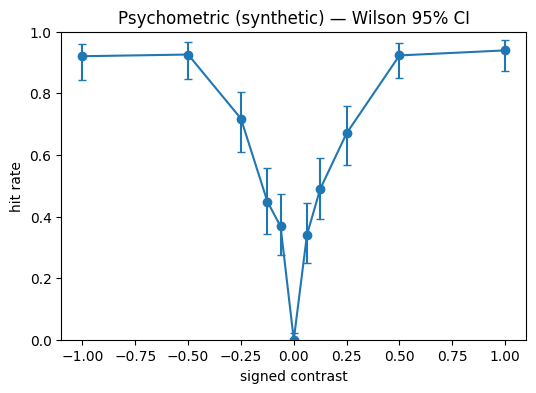

In [4]:
x = psych["signed_contrast"].to_numpy()
y = psych["value"].to_numpy()
yerr = np.vstack([y - psych["ci_low"].to_numpy(), psych["ci_high"].to_numpy() - y])

plt.figure(figsize=(6, 4))
plt.errorbar(x, y, yerr=yerr, marker="o", capsize=3)
plt.ylim(0, 1)
plt.xlabel("signed contrast")
plt.ylabel("hit rate")
plt.title("Psychometric (synthetic) — Wilson 95% CI")
plt.show()

## 3. Median reaction time per condition

`value="reaction_time", stat="median"` → median with the analytic **order-statistic** CI
(fast, deterministic, no bootstrap loop). Prefer bootstrap? use
`metrics=[Median("reaction_time", ci="bootstrap")]`.

In [5]:
aggregate(df, group="signed_contrast", value="reaction_time", stat="median").sort(
    "signed_contrast"
)

signed_contrast,metric,value,ci_low,ci_high,n
f64,str,f64,f64,f64,i64
-1.0,"""median[reaction_time]""",321.801686,301.336928,345.809591,81
-0.5,"""median[reaction_time]""",308.759559,282.403926,333.421786,75
-0.25,"""median[reaction_time]""",314.292276,276.817504,359.448569,56
-0.125,"""median[reaction_time]""",276.670143,248.808477,301.752514,35
-0.0625,"""median[reaction_time]""",362.953372,266.574377,420.74429,32
0.0,"""median[reaction_time]""",null,null,null,0
0.0625,"""median[reaction_time]""",298.326386,265.957655,327.360413,30
0.125,"""median[reaction_time]""",328.630191,301.003674,365.555024,46
0.25,"""median[reaction_time]""",306.334361,259.711544,343.64652,61


## 4. Several metrics in one pass

Pass a list of metric specs; the output stays tidy (one row per group × metric).

In [6]:
aggregate(
    df,
    group="opto",
    metrics=[Rate("outcome", success="hit"), Median("reaction_time"), Mean("reaction_time"), Count()],
).sort(["opto", "metric"])

opto,metric,value,ci_low,ci_high,n
bool,str,f64,f64,f64,i64
false,"""count""",730.0,null,null,730
false,"""mean[reaction_time]""",307.302329,295.746777,318.857882,404
false,"""median[reaction_time]""",298.451818,280.364108,311.453564,404
false,"""rate[outcome=hit]""",0.553425,0.517175,0.589115,730
true,"""count""",320.0,null,null,320
true,"""mean[reaction_time]""",373.207694,357.63694,388.778447,189
true,"""median[reaction_time]""",350.611447,333.036206,371.310432,189
true,"""rate[outcome=hit]""",0.590625,0.535984,0.643116,320


## 5. Group by anything — e.g. animal × condition

Just add columns to `group`. Here: one psychometric per animal.

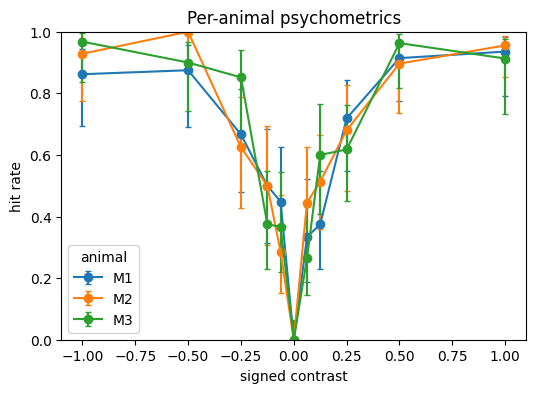

In [7]:
per = aggregate(df, group=["animalid", "signed_contrast"], metrics=[Rate("outcome", success="hit")]).sort(
    ["animalid", "signed_contrast"]
)

plt.figure(figsize=(6, 4))
for animal in per["animalid"].unique(maintain_order=True):
    sub = per.filter(pl.col("animalid") == animal)
    xx, yy = sub["signed_contrast"].to_numpy(), sub["value"].to_numpy()
    err = np.vstack([yy - sub["ci_low"].to_numpy(), sub["ci_high"].to_numpy() - yy])
    plt.errorbar(xx, yy, yerr=err, marker="o", capsize=2, label=animal)
plt.ylim(0, 1)
plt.xlabel("signed contrast")
plt.ylabel("hit rate")
plt.legend(title="animal")
plt.title("Per-animal psychometrics")
plt.show()

## 6. Rate from a categorical column

`Rate("outcome", success="hit")` works off a string column — same result as the 0/1 `is_hit`.

In [8]:
aggregate(df, group="signed_contrast", metrics=[Rate("outcome", success="hit")]).sort(
    "signed_contrast"
)

signed_contrast,metric,value,ci_low,ci_high,n
f64,str,f64,f64,f64,i64
-1.0,"""rate[outcome=hit]""",0.920455,0.844801,0.960935,88
-0.5,"""rate[outcome=hit]""",0.925926,0.847671,0.96561,81
-0.25,"""rate[outcome=hit]""",0.717949,0.609691,0.805747,78
-0.125,"""rate[outcome=hit]""",0.448718,0.343344,0.558906,78
-0.0625,"""rate[outcome=hit]""",0.367816,0.274087,0.472725,87
0.0,"""rate[outcome=hit]""",0.0,0.0,0.02148,175
0.0625,"""rate[outcome=hit]""",0.340909,0.250391,0.444735,88
0.125,"""rate[outcome=hit]""",0.489362,0.390728,0.588831,94
0.25,"""rate[outcome=hit]""",0.67033,0.56857,0.758291,91


## 7. Raw arrays for statistical tests

`group_arrays` hands you the per-group arrays to feed a test. (Chunk 2 will add
`piepy.stats.compare`; here we preview with scipy directly.)

In [9]:
from scipy.stats import mannwhitneyu

arrs = group_arrays(df, group="opto", value="reaction_time")
u, p = mannwhitneyu(arrs[True], arrs[False])
print(f"opto (n={arrs[True].size}) vs control (n={arrs[False].size}) reaction time")
print(f"Mann-Whitney U={u:.0f}, p={p:.3g}")

opto (n=189) vs control (n=404) reaction time
Mann-Whitney U=50759, p=9.73e-11


## 8. Robustness

Empty groups become `n=0` with `null` estimates (never a crash), null group **keys** are
kept as their own group, and a missing column raises a clear error.

In [10]:
demo = pl.DataFrame({"cond": ["a", "a", "b", None], "rt": [1.0, 2.0, None, 5.0]})
aggregate(demo, group="cond", value="rt", stat="median")  # b has no rt -> n=0; null key kept

cond,metric,value,ci_low,ci_high,n
str,str,f64,f64,f64,i64
null,"""median[rt]""",5.0,5.0,5.0,1
"""a""","""median[rt]""",1.5,1.0,2.0,2
"""b""","""median[rt]""",null,null,null,0


## (Optional) A real session

Needs lab data + `~/.piepy/config.json`. Analysis writes are redirected to a temp dir so
nothing is clobbered, and the cell skips cleanly if the session isn't available locally.

In [11]:
import tempfile
from piepy.core.config import config

config.paths["analysis"] = [tempfile.mkdtemp()]  # do not touch real analysis output
config.verbose = False  # quiet the parse logs / progress bars

try:
    from piepy.psychophysics.wheel.detection.wheelDetectionSession import (
        WheelDetectionSession,
    )

    sess = WheelDetectionSession("230106_KC144_detect__no_cam_KC", load_flag=False)
    real = sess.concatenate_runs("wheel_detection")
    out = aggregate(
        real,
        group="signed_contrast",
        metrics=[Rate("outcome", success="hit"), Median("reaction_time"), Count()],
    ).sort(["signed_contrast", "metric"])
    print(real.shape)
    display(out)
except Exception as e:
    print("Skipping real-data example:", type(e).__name__, e)

NO RIG TIME TO INTERPOLATE, COPYING STATE TIME
(498, 64)


signed_contrast,metric,value,ci_low,ci_high,n
f64,str,f64,f64,f64,i64
null,"""count""",106.0,null,null,106
null,"""median[reaction_time]""",-829.8,-1089.6,-590.4,104
null,"""rate[outcome=hit]""",0.0,0.0,0.034973,106
-1.0,"""count""",32.0,null,null,32
-1.0,"""median[reaction_time]""",187.6,171.0,198.4,30
-1.0,"""rate[outcome=hit]""",0.9375,0.798529,0.982689,32
-0.5,"""count""",29.0,null,null,29
-0.5,"""median[reaction_time]""",193.3,185.8,198.0,26
-0.5,"""rate[outcome=hit]""",0.862069,0.69441,0.945026,29
